In [1]:
from google.colab import files
uploaded = files.upload()  # A file picker will pop up — select your CSV

Saving sales_data_sample.csv to sales_data_sample.csv


In [2]:
import pandas as pd

df = pd.read_csv('sales_data_sample.csv', encoding='latin-1')
print(df.shape)
print(df.head())
print(df.dtypes)

(2823, 25)
   ORDERNUMBER  QUANTITYORDERED  PRICEEACH  ORDERLINENUMBER    SALES  \
0        10107               30      95.70                2  2871.00   
1        10121               34      81.35                5  2765.90   
2        10134               41      94.74                2  3884.34   
3        10145               45      83.26                6  3746.70   
4        10159               49     100.00               14  5205.27   

         ORDERDATE   STATUS  QTR_ID  MONTH_ID  YEAR_ID  ...  \
0   2/24/2003 0:00  Shipped       1         2     2003  ...   
1    5/7/2003 0:00  Shipped       2         5     2003  ...   
2    7/1/2003 0:00  Shipped       3         7     2003  ...   
3   8/25/2003 0:00  Shipped       3         8     2003  ...   
4  10/10/2003 0:00  Shipped       4        10     2003  ...   

                    ADDRESSLINE1  ADDRESSLINE2           CITY STATE  \
0        897 Long Airport Avenue           NaN            NYC    NY   
1             59 rue de l'Abbaye   

In [3]:
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

ORDERNUMBER            0
QUANTITYORDERED        0
PRICEEACH              0
ORDERLINENUMBER        0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE            0
MSRP                   0
PRODUCTCODE            0
CUSTOMERNAME           0
PHONE                  0
ADDRESSLINE1           0
ADDRESSLINE2        2521
CITY                   0
STATE               1486
POSTALCODE            76
COUNTRY                0
TERRITORY           1074
CONTACTLASTNAME        0
CONTACTFIRSTNAME       0
DEALSIZE               0
dtype: int64
Duplicates: 0


In [4]:
# Fix ORDERDATE — convert from string to proper date type
df['ORDERDATE'] = pd.to_datetime(df['ORDERDATE'])

# Drop columns we don't need
df = df.drop(columns=[
    'PHONE',
    'ADDRESSLINE1',
    'ADDRESSLINE2',
    'POSTALCODE',
    'CONTACTFIRSTNAME',
    'CONTACTLASTNAME',
    'STATE',
    'TERRITORY'
])

# Confirm shape after cleaning
print("Cleaned shape:", df.shape)

# Confirm no more problematic nulls
print(df.isnull().sum())

# Quick sanity check
print(df.head())

Cleaned shape: (2823, 17)
ORDERNUMBER        0
QUANTITYORDERED    0
PRICEEACH          0
ORDERLINENUMBER    0
SALES              0
ORDERDATE          0
STATUS             0
QTR_ID             0
MONTH_ID           0
YEAR_ID            0
PRODUCTLINE        0
MSRP               0
PRODUCTCODE        0
CUSTOMERNAME       0
CITY               0
COUNTRY            0
DEALSIZE           0
dtype: int64
   ORDERNUMBER  QUANTITYORDERED  PRICEEACH  ORDERLINENUMBER    SALES  \
0        10107               30      95.70                2  2871.00   
1        10121               34      81.35                5  2765.90   
2        10134               41      94.74                2  3884.34   
3        10145               45      83.26                6  3746.70   
4        10159               49     100.00               14  5205.27   

   ORDERDATE   STATUS  QTR_ID  MONTH_ID  YEAR_ID  PRODUCTLINE  MSRP  \
0 2003-02-24  Shipped       1         2     2003  Motorcycles    95   
1 2003-05-07  Shipped       2

In [5]:
import sqlite3

# Create a database in memory
conn = sqlite3.connect('sales.db')

# Load your clean dataframe into it as a SQL table
df.to_sql('sales', conn, if_exists='replace', index=False)

print("Database ready!")

Database ready!


In [6]:
query1 = """
SELECT YEAR_ID, MONTH_ID, ROUND(SUM(SALES), 2) AS Total_Sales
FROM sales
GROUP BY YEAR_ID, MONTH_ID
ORDER BY Total_Sales DESC
LIMIT 10
"""
pd.read_sql(query1, conn)

,YEAR_ID,MONTH_ID,Total_Sales
0,2004,11,1089048.01
1,2003,11,1029837.66
2,2003,10,568290.97
3,2004,10,552924.25
4,2004,8,461501.27
5,2005,5,457861.06
6,2005,3,374262.76
7,2004,12,372802.66
8,2005,2,358186.18
9,2005,1,339543.42


In [7]:
query2 = """
SELECT COUNTRY, ROUND(SUM(SALES), 2) AS Total_Sales
FROM sales
GROUP BY COUNTRY
ORDER BY Total_Sales DESC
"""
pd.read_sql(query2, conn)

,COUNTRY,Total_Sales
0,USA,3627982.83
1,Spain,1215686.92
2,France,1110916.52
3,Australia,630623.10
4,UK,478880.46
5,Italy,374674.31
6,Finland,329581.91
7,Norway,307463.70
8,Singapore,288488.41
9,Denmark,245637.15


In [8]:
query3 = """
SELECT PRODUCTLINE,
       ROUND(SUM(SALES), 2) AS Total_Sales,
       COUNT(ORDERNUMBER) AS Total_Orders
FROM sales
GROUP BY PRODUCTLINE
ORDER BY Total_Sales DESC
"""
pd.read_sql(query3, conn)

,PRODUCTLINE,Total_Sales,Total_Orders
0,Classic Cars,3919615.66,967
1,Vintage Cars,1903150.84,607
2,Motorcycles,1166388.34,331
3,Trucks and Buses,1127789.84,301
4,Planes,975003.57,306
5,Ships,714437.13,234
6,Trains,226243.47,77


In [9]:
query4 = """
SELECT CUSTOMERNAME, ROUND(SUM(SALES), 2) AS Total_Sales
FROM sales
GROUP BY CUSTOMERNAME
ORDER BY Total_Sales DESC
LIMIT 10
"""
pd.read_sql(query4, conn)

,CUSTOMERNAME,Total_Sales
0,Euro Shopping Channel,912294.11
1,Mini Gifts Distributors Ltd.,654858.06
2,"Australian Collectors, Co.",200995.41
3,Muscle Machine Inc,197736.94
4,La Rochelle Gifts,180124.90
5,"Dragon Souveniers, Ltd.",172989.68
6,Land of Toys Inc.,164069.44
7,The Sharp Gifts Warehouse,160010.27
8,"AV Stores, Co.",157807.81
9,"Anna's Decorations, Ltd",153996.13


In [10]:
query5 = """
SELECT DEALSIZE,
       ROUND(SUM(SALES), 2) AS Total_Sales,
       COUNT(ORDERNUMBER) AS Total_Orders,
       ROUND(AVG(SALES), 2) AS Avg_Sale
FROM sales
GROUP BY DEALSIZE
ORDER BY Total_Sales DESC
"""
pd.read_sql(query5, conn)

,DEALSIZE,Total_Sales,Total_Orders,Avg_Sale
0,Medium,6087432.24,1384,4398.43
1,Small,2643077.35,1282,2061.68
2,Large,1302119.26,157,8293.75


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean style
sns.set_theme(style="whitegrid")

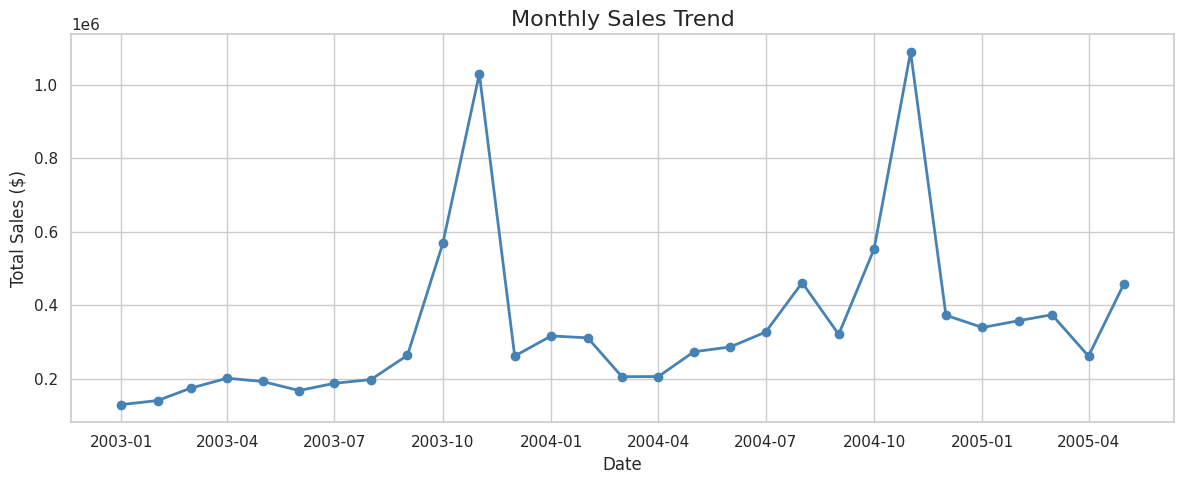

In [12]:
monthly_sales = df.groupby(['YEAR_ID', 'MONTH_ID'])['SALES'].sum().reset_index()
monthly_sales['DATE'] = pd.to_datetime(monthly_sales[['YEAR_ID', 'MONTH_ID']].assign(DAY=1).rename(columns={'YEAR_ID':'year','MONTH_ID':'month'}))

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales['DATE'], monthly_sales['SALES'], marker='o', color='steelblue', linewidth=2)
plt.title('Monthly Sales Trend', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('chart1_monthly_trend.png', dpi=150)
plt.show()

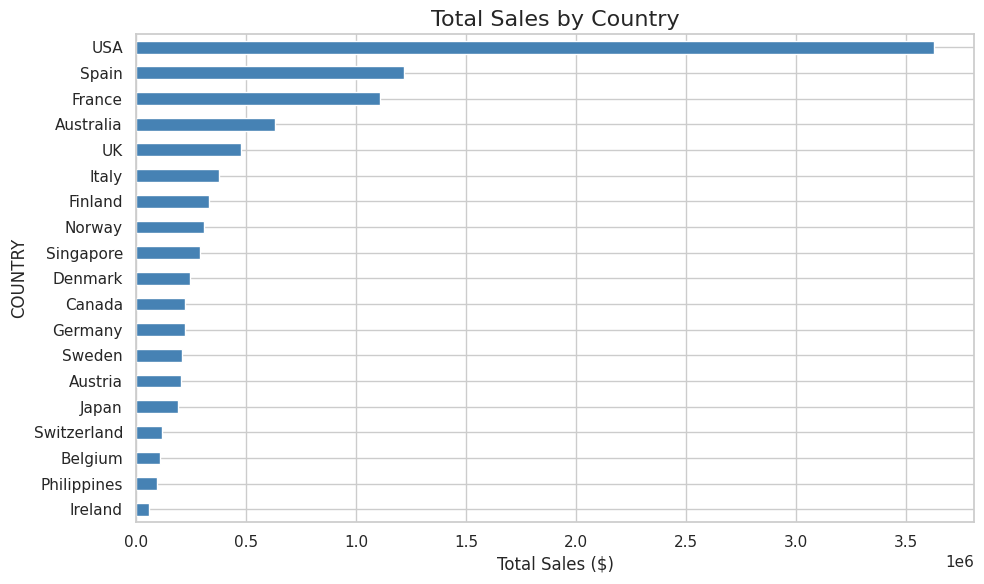

In [15]:
country_sales = df.groupby('COUNTRY')['SALES'].sum().sort_values(ascending=True)

plt.figure(figsize=(10, 6))
country_sales.plot(kind='barh', color='steelblue')
plt.title('Total Sales by Country', fontsize=16)
plt.xlabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('chart2_country_sales.png', dpi=150)
plt.show()

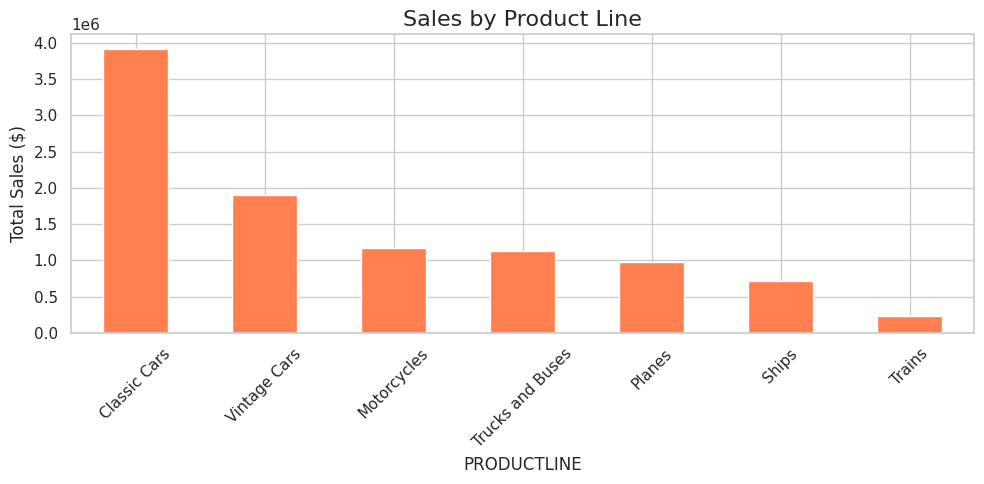

In [14]:
product_sales = df.groupby('PRODUCTLINE')['SALES'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
product_sales.plot(kind='bar', color='coral')
plt.title('Sales by Product Line', fontsize=16)
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart3_product_sales.png', dpi=150)
plt.show()

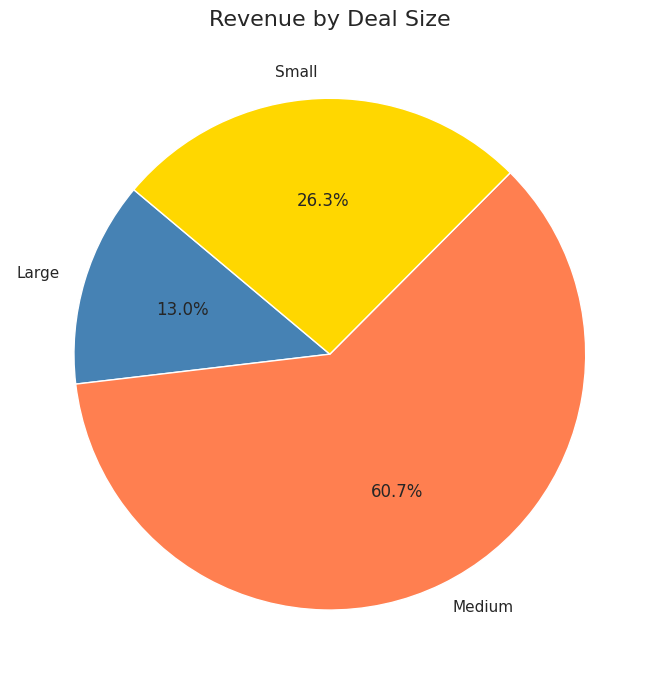

In [13]:
deal_sales = df.groupby('DEALSIZE')['SALES'].sum()

plt.figure(figsize=(7, 7))
plt.pie(deal_sales, labels=deal_sales.index, autopct='%1.1f%%',
        colors=['steelblue','coral','gold'], startangle=140)
plt.title('Revenue by Deal Size', fontsize=16)
plt.tight_layout()
plt.savefig('chart4_deal_size.png', dpi=150)
plt.show()

In [16]:
report = """
# Sales Performance Analysis Report
**Dataset:** Sample Sales Data | **Tool:** Python, SQL, Matplotlib
**Prepared by:** [Your Name]

---

## 1. Executive Summary
This analysis examines 2,823 sales transactions across multiple countries,
product lines, and customer segments. The goal is to identify key revenue
drivers and provide actionable business recommendations.

---

## 2. Key Findings

### 📈 Sales Trend
- Sales peaked in **2004** across all months
- The strongest individual month was **November 2004**
- Note: 2005 data is incomplete (only covers Q1), so the apparent
  decline is not a true business trend

### 🌍 Geography
- **USA** is the top revenue-generating country by a significant margin
- European markets contribute strongly through key wholesale accounts

### 🚗 Product Performance
- **Classic Cars** is the #1 product line by total revenue
- **Vintage Cars** ranks second, confirming strong demand for
  collector vehicle models

### 👑 Customer Insights
- **Euro Shopping Channel** is the single highest-value customer
- Heavy reliance on one client is a business risk worth monitoring
- Top 10 customers represent a disproportionate share of total revenue

### 💼 Deal Size Strategy
- **Medium deals** generate the most total revenue ($6.08M)
- **Large deals** have the highest average value ($8,293 each)
  but are rare (only 157 transactions)
- Increasing large deal conversion rate could significantly
  boost revenue

---

## 3. Recommendations

1. **Double down on Classic Cars inventory** — highest demand product line
2. **Prioritize USA market** — largest revenue opportunity
3. **Diversify top customer dependency** — Euro Shopping Channel
   concentration is a risk
4. **Create a large deal pipeline** — high avg value but low volume
   suggests untapped potential
5. **Replicate November 2004 conditions** — investigate what drove
   that peak month

---

## 4. Tools Used
- **Python (pandas)** — data cleaning and preparation
- **SQLite (via Python)** — business question analysis
- **Matplotlib & Seaborn** — data visualization

"""

# Save the report
with open('sales_analysis_report.md', 'w') as f:
    f.write(report)

print("Report saved!")

Report saved!


In [25]:
import zipfile
from google.colab import files

# Create a zip file with all outputs
with zipfile.ZipFile('sales_project.zip', 'w') as zipf:
    zipf.write('chart1_monthly_trend.png')
    zipf.write('chart2_country_sales.png')
    zipf.write('chart3_product_sales.png')
    zipf.write('chart4_deal_size.png')
    zipf.write('sales_analysis_report.md')

# Download the zip
files.download('sales_project.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>